# RANDOM FORES PARA DETERMINAR DIABETES
# FUENTE [KAGGLE](https://www.kaggle.com/datasets/kumargh/pimaindiansdiabetescsv)

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [26]:
df_diabetes = pd.read_csv('/content/pima-indians-diabetes.csv',header=None)
df_diabetes.head(10)

,0,1,2,3,4,5,6,7,8
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1
7,10,115,0,0,0,35.3,0.134,29,0
8,2,197,70,45,543,30.5,0.158,53,1
9,8,125,96,0,0,0.0,0.232,54,1


In [28]:
#columns = ['Pregnancies','Glucose','BloodPressure','SkinThickness','Insulin','BMI','DiabetesPedigreeFunction','Age','Class']
columns = ['pregnancies','glucose','blood_pressure','skinthickness','insulin','bmi','diabetes_pedigree_function','age','class']

df_diabetes.columns = columns
df_diabetes.head(10)

,pregnancies,glucose,blood_pressure,skinthickness,insulin,bmi,diabetes_pedigree_function,age,class
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1
7,10,115,0,0,0,35.3,0.134,29,0
8,2,197,70,45,543,30.5,0.158,53,1
9,8,125,96,0,0,0.0,0.232,54,1


In [29]:
df_diabetes.isna().sum().sum()

np.int64(0)

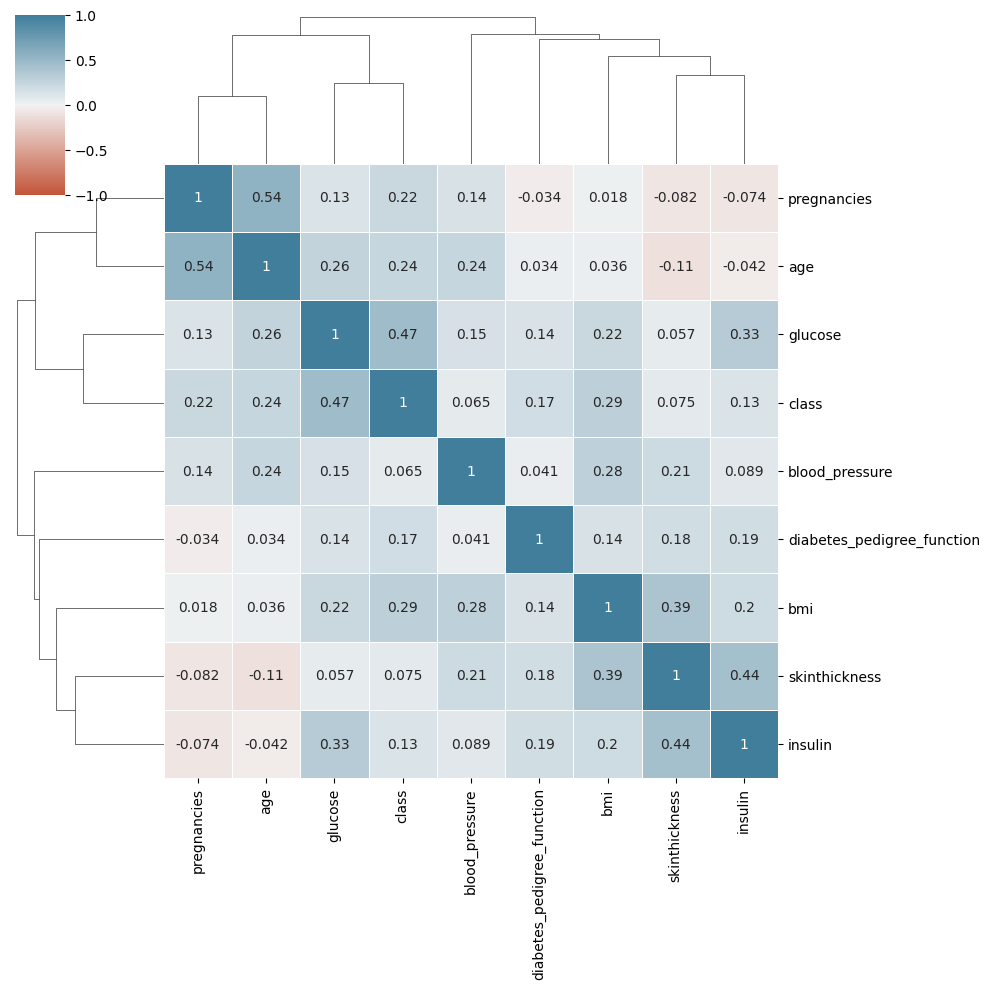

In [30]:
sns.clustermap(
    data=df_diabetes.corr(numeric_only=True),
    cmap=sns.diverging_palette(20,230,as_cmap=True),
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    cbar_kws={'shrink':0.5},
    annot=True
)

# ENTRENAMIENTO DE MODELO

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [31]:
X = df_diabetes.drop(columns=['pregnancies','blood_pressure','skinthickness','insulin','diabetes_pedigree_function','class'])

In [32]:
X

,glucose,bmi,age
0,148,33.6,50
1,85,26.6,31
2,183,23.3,32
3,89,28.1,21
4,137,43.1,33
...,...,...,...
763,101,32.9,63
764,122,36.8,27
765,121,26.2,30
766,126,30.1,47


In [33]:
y = df_diabetes['class']
y

,class
0,1
1,0
2,1
3,0
4,1
...,...
763,0
764,0
765,0
766,1


In [34]:
df_diabetes.dtypes

,0
pregnancies,int64
glucose,int64
blood_pressure,int64
skinthickness,int64
insulin,int64
bmi,float64
diabetes_pedigree_function,float64
age,int64
class,int64


In [35]:
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [36]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

# EVALUAMOS DIFERENTES MODELOS DE CLASIFICACIÓN

In [37]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

In [38]:
# Definir modelos de clasificación
modelos_clasificacion = {
    "Regresión Logística": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42),
    "SVM (RBF)": SVC(kernel='rbf'),
    "XGBoost": XGBClassifier(n_estimators=100, learning_rate=0.1, use_label_encoder=False, eval_metric='logloss', random_state=42)
}

In [39]:
# Evaluar cada modelo
def evaluar_clasificador(modelo, nombre):
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    print(f'\n{nombre}:')
    print(f'Accuracy: {accuracy:.4f}')
    print(classification_report(y_test, y_pred))
    return accuracy

In [40]:
# Comparar modelos
resultados_clasificacion = {}
for nombre, modelo in modelos_clasificacion.items():
    resultados_clasificacion[nombre] = evaluar_clasificador(modelo, nombre)

# Mostrar el mejor modelo
mejor_modelo_clasificacion = max(resultados_clasificacion, key=resultados_clasificacion.get)
print(f'\nEl mejor modelo es: {mejor_modelo_clasificacion} con un Accuracy de {resultados_clasificacion[mejor_modelo_clasificacion]:.4f}')


Regresión Logística:
Accuracy: 0.7468
              precision    recall  f1-score   support

           0       0.80      0.81      0.80        99
           1       0.65      0.64      0.64        55

    accuracy                           0.75       154
   macro avg       0.72      0.72      0.72       154
weighted avg       0.75      0.75      0.75       154


Random Forest:
Accuracy: 0.7338
              precision    recall  f1-score   support

           0       0.81      0.77      0.79        99
           1       0.62      0.67      0.64        55

    accuracy                           0.73       154
   macro avg       0.71      0.72      0.72       154
weighted avg       0.74      0.73      0.74       154


Gradient Boosting:
Accuracy: 0.7273
              precision    recall  f1-score   support

           0       0.81      0.76      0.78        99
           1       0.61      0.67      0.64        55

    accuracy                           0.73       154
   macro avg       

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [01:17:40] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


In [41]:
resultados_clasificacion[mejor_modelo_clasificacion]

0.7532467532467533

In [42]:
mejor_modelo_clasificacion

'SVM (RBF)'

# GRAFICAMOS RESULTADOS

<ipython-input-43-7490fcd63bac>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=list(resultados_clasificacion.keys()), y=list(resultados_clasificacion.values()), palette='mako')


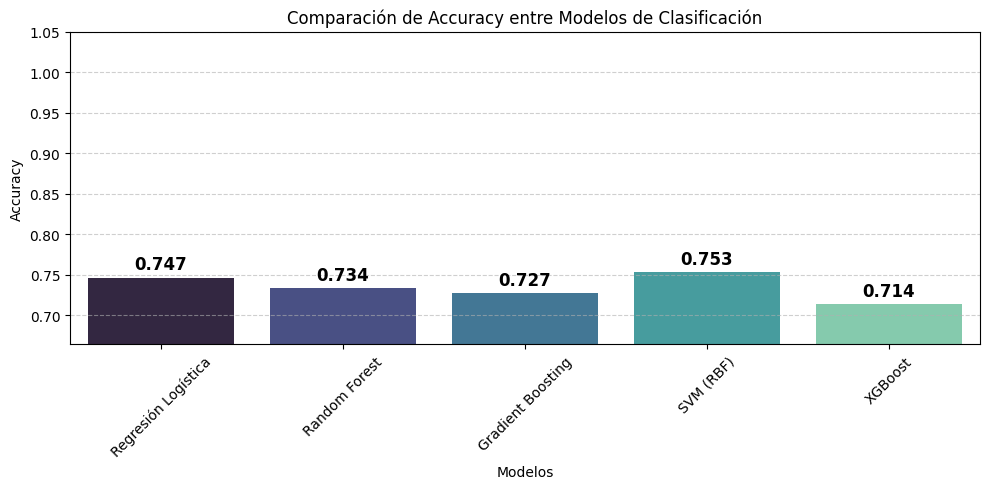

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

# Comparación del Accuracy entre modelos de clasificación
plt.figure(figsize=(10, 5))
ax = sns.barplot(x=list(resultados_clasificacion.keys()), y=list(resultados_clasificacion.values()), palette='mako')

# Agregar etiquetas en cada barra
for index, value in enumerate(resultados_clasificacion.values()):
    ax.text(index, value + 0.01, f'{value:.3f}', ha='center', fontsize=12, fontweight='bold')

plt.ylim(min(resultados_clasificacion.values()) - 0.05, 1.05)
plt.xlabel('Modelos')
plt.ylabel('Accuracy')
plt.title('Comparación de Accuracy entre Modelos de Clasificación')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


# GUARDAMOS EL MODELO Y EL SCALER

In [44]:
import joblib
modelo_seleccionado = modelos_clasificacion[mejor_modelo_clasificacion]
modelo_seleccionado

SVC()

In [45]:
joblib.dump(modelo_seleccionado,'model.pkl')

['model.pkl']

In [46]:
joblib.dump(scaler,'scaler.pkl')

['scaler.pkl']

# CARGAMOS LOS MODELOS GUARDAOS Y PROBAMOS CON DATA NUEVA

In [48]:
load_scaler = joblib.load('/content/scaler.pkl')
load_model = joblib.load('/content/model.pkl')

nueva_data = pd.DataFrame([[148, 33.6, 50]], columns=['glucose', 'bmi', 'age'])

nueva_data_scaled = load_scaler.transform(nueva_data)

prediction = load_model.predict(nueva_data_scaled)
print(f'Predicción :  {prediction}')

Predicción :  [1]
